In [ ]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# chr1, pos1, chr2, pos2, class, name
sv_file = pd.read_hdf('data/sv_file_dup_cleaned.h5')
# chr (1-24), start.bp, end.bp, sample
clustered_file = pd.read_csv('../SV_signature_analysis/Clustered_SVs/results/all_samples_clustering_regions.txt', sep='\t')
final_samples = pd.read_csv('data/final_analysis_samples.csv')
# filter to analysis samples
sv_file = sv_file[sv_file['name'].isin(final_samples['tumor_normal_pair'])]
clustered_file = clustered_file[clustered_file['sample'].isin(final_samples['tumor_normal_pair'])]
print("Number of samples:", sv_file['name'].nunique())
sv_file.head()

Number of samples: 205


,num,chr1,str1,pos1,chr2,str2,pos2,class,span,somatic,somatic_score,SvABA,Manta,VCF_TALT,VCF_NALT,VCF_TREF,VCF_NREF,name
0,614,1,0,3680543,1,1,3731731,deletion,51189.0,1,15.0,0,1,11,0,149,86,09T02-09N01
1,615,1,0,25148899,1,1,25252735,deletion,103843.0,1,15.0,0,1,12,0,126,72,09T02-09N01
2,909,1,0,124154195,1,1,124163217,deletion,9022.0,1,5.0,0,1,9,0,199,69,09T02-09N01
3,719,1,1,160827717,1,0,160890810,tandem_dup,63090.0,1,11.0,0,1,15,0,163,65,09T02-09N01
4,33,1,1,246260290,19,1,6750721,inter_chr,NaN,1,41.0,1,1,25,0,127,73,09T02-09N01


In [3]:
# Convert strand encoding (0 -> "+", 1 -> "-")
sv_file['strand1'] = sv_file['str1'].map({0: '+', 1: '-'})
sv_file['strand2'] = sv_file['str2'].map({0: '+', 1: '-'})

def encode_sv_type(row):
    strand1 = row['strand1']
    strand2 = row['strand2'] 
    chrom1 = row['chr1']
    chrom2 = row['chr2']
    original_class = row['class']
    
    if chrom1 != chrom2:
        return 'trans'
    
    # For same chromosome, encode based on strand orientations
    if strand1 == '+' and strand2 == '-':
        return 'del'  # deletion-like (+/-)
    elif strand1 == '-' and strand2 == '+':
        return 'dup'  # duplication-like (-/+)
    elif strand1 == '+' and strand2 == '+':
        return 'inv'  # head-to-head inversion (+/+)
    elif strand1 == '-' and strand2 == '-':
        return 'inv'  # tail-to-tail inversion (-/-)
    else:
        print(f"Warning: Unusual strand pattern {strand1}/{strand2} for {original_class}")
        return original_class.upper()

# Apply the strand-based encoding
sv_file['svclass'] = sv_file.apply(encode_sv_type, axis=1)

print("SV type encoding based on strands:")
encoding_summary = sv_file.groupby(['strand1', 'strand2', 'svclass']).size().reset_index(name='count')
print(encoding_summary)

# Compare with original classifications
comparison = sv_file.groupby(['class', 'svclass']).size().reset_index(name='count')
print("\nOriginal vs. strand-based classification:")
print(comparison)

SV type encoding based on strands:
  strand1 strand2 svclass  count
0       +       +     inv   8840
1       +       +   trans   4210
2       +       -     del  10156
3       +       -   trans   3332
4       -       +     dup   8883
5       -       +   trans   4285
6       -       -     inv   9353
7       -       -   trans   4820

Original vs. strand-based classification:
        class svclass  count
0    deletion     del   5210
1   inter_chr   trans  16647
2   inversion     inv   8903
3  long_range     del   4946
4  long_range     dup   4685
5  long_range     inv   9290
6  tandem_dup     dup   4198


In [4]:
def annotate_svs_with_clusters(sv_df, clustering_regions):
    # Mark each SV as clustered if either breakpoint falls in any clustered region for the sample.
    sv = sv_df.copy()
    sv['chr1'] = sv['chr1'].astype(str)
    sv['chr2'] = sv['chr2'].astype(str)
    regions = clustering_regions.copy()
    regions['chr'] = regions['chr'].astype(str)

    sv['is_clustered'] = False

    # group regions by sample for fast lookup
    for sample, sample_regs in regions.groupby('sample'):
        sample_mask = sv['name'] == sample
        if not sample_mask.any():
            continue

        sub = sv.loc[sample_mask]
        is_clust = pd.Series(False, index=sub.index)

        for _, r in sample_regs.iterrows():
            chrom, start, end = r['chr'], r['start.bp'], r['end.bp']
            bp1_in = (sub['chr1'] == chrom) & sub['pos1'].between(start, end)
            bp2_in = (sub['chr2'] == chrom) & sub['pos2'].between(start, end)
            is_clust |= (bp1_in | bp2_in)

        sv.loc[sub.index, 'is_clustered'] = is_clust.values

    return sv

sv_file = annotate_svs_with_clusters(sv_file, clustered_file)
sv_file['cluster_status'] = np.where(sv_file['is_clustered'], 'clustered', 'non_clustered')

# run the following if setting final_samples to 237 samples (all included)
'''
cluster_counts_by_sample = (
    sv_file
    .groupby(['name', 'cluster_status'])
    .size()
    .unstack('cluster_status', fill_value=0)
    .reset_index()
    .rename(columns={
        'name': 'sample',
        'clustered': 'n_clustered',
        'non_clustered': 'n_non_clustered',
    })
)
cluster_counts_by_sample.to_csv('data/clustered_and_nonclustered_sv_counts_by_sample.csv', index=False)
'''

"\ncluster_counts_by_sample = (\n    sv_file\n    .groupby(['name', 'cluster_status'])\n    .size()\n    .unstack('cluster_status', fill_value=0)\n    .reset_index()\n    .rename(columns={\n        'name': 'sample',\n        'clustered': 'n_clustered',\n        'non_clustered': 'n_non_clustered',\n    })\n)\ncluster_counts_by_sample.to_csv('data/clustered_and_nonclustered_sv_counts_by_sample.csv', index=False)\n"

205


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_1370/1815060799.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_1370/1815060799.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_1370/1815060799.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0, 1, 0.96])


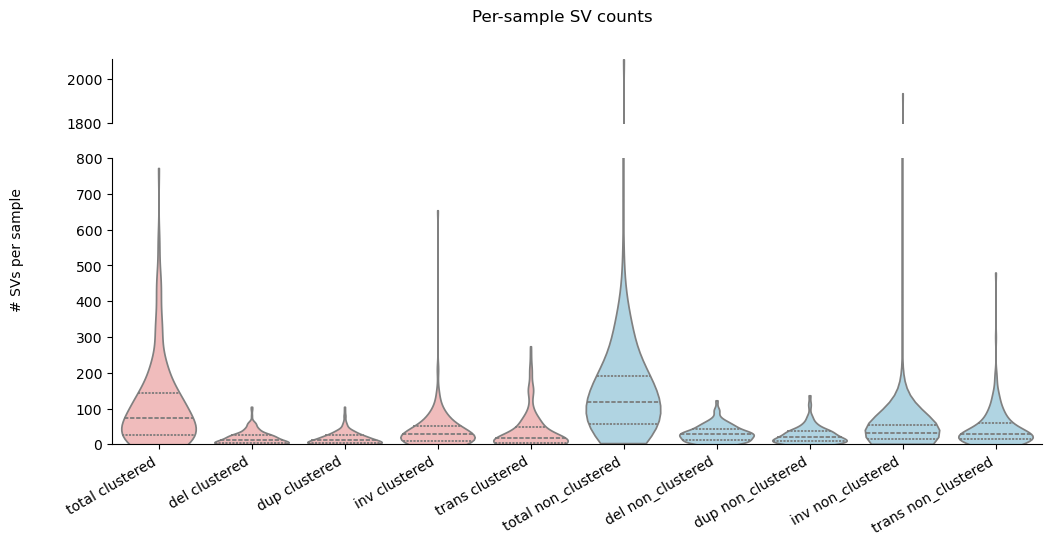

2089


In [5]:
samples  = sv_file['name'].unique()
print(len(samples))
sv_types = ['del', 'dup', 'inv', 'trans']
statuses = ['clustered', 'non_clustered']
idx = pd.MultiIndex.from_product([samples, sv_types, statuses],names=['name','svclass','cluster_status'])

long_counts = (
    sv_file.groupby(['name','svclass','cluster_status']).size()
           .reindex(idx, fill_value=0)
           .reset_index(name='n_svs')
)
long_counts['category'] = long_counts['svclass'] + ' ' + long_counts['cluster_status']

totals = (
    long_counts
    .groupby(['name', 'cluster_status'])['n_svs']
    .sum()
    .reset_index()
)
totals['svclass']  = 'total'
totals['category'] = 'total ' + totals['cluster_status']

long_counts_with_totals = pd.concat([long_counts, totals], ignore_index=True)

order = (
    ['total clustered']
    + [f'{t} clustered'     for t in ['del', 'dup', 'inv', 'trans']]
    + ['total non_clustered']
    + [f'{t} non_clustered' for t in ['del', 'dup', 'inv', 'trans']]
)
palette = {c: ('#F8B4B4' if 'non_clustered' not in c else '#A8D8EA') for c in order}

# top = high range, bottom = main range; height_ratios makes bottom bigger
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(12, 5),
    gridspec_kw={'height_ratios': [1, 4.5], 'hspace': 0.2}
)

# same data on both axes
for ax in (ax_top, ax_bot):
    sns.violinplot(
        data=long_counts_with_totals, x='category', y='n_svs',
        order=order, palette=palette,
        cut=0, inner='quartile', ax=ax
    )
        # force all violin edges black
    for c in ax.collections:
        c.set_edgecolor('gray')
    ax.set_xlabel('')
    ax.set_ylabel('')

# y-limits, set to max value in long_counts_with_totals
ax_top.set_ylim(1800, long_counts_with_totals['n_svs'].max())
ax_bot.set_ylim(0, 800)

# hide the spines/ticks between the two axes
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.spines['top'].set_visible(False)
ax_bot.spines['right'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
ax_bot.xaxis.tick_bottom()

# shared y-label
fig.text(0.04, 0.5, '# SVs per sample', va='center', rotation='vertical')
plt.xticks(rotation=30, ha='right')
fig.suptitle('Per-sample SV counts')
plt.tight_layout(rect=[0.05, 0, 1, 0.96])
plt.savefig('plots/sv_landscape_plot.pdf', dpi=300)
plt.show()

print(long_counts_with_totals['n_svs'].max())

In [6]:
summary = (
    long_counts_with_totals
    .groupby('category')['n_svs']
    .describe(percentiles=[.25, .5, .75])[['25%', '50%', '75%']]
    .reindex(order)
)
print(summary)

                      25%    50%    75%
category                               
total clustered      27.0   74.0  144.0
del clustered         4.0   13.0   26.0
dup clustered         4.0   12.0   25.0
inv clustered         9.0   28.0   50.0
trans clustered       4.0   17.0   49.0
total non_clustered  58.0  119.0  191.0
del non_clustered    13.0   28.0   44.0
dup non_clustered     8.0   20.0   37.0
inv non_clustered    15.0   32.0   54.0
trans non_clustered  14.0   28.0   61.0


Total SVs: 53879
                n  fraction  percent
caller                              
SvABA only   3505  0.065053      6.5
Manta only  15648  0.290429     29.0
Both        34726  0.644518     64.5


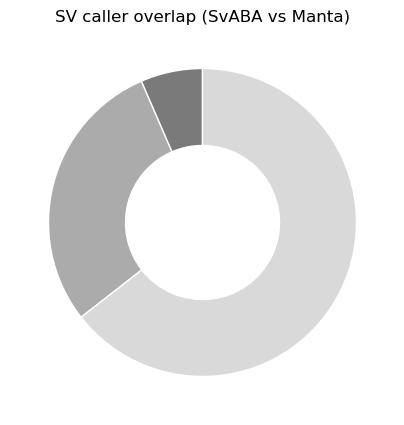

In [ ]:
# donut chart showing number of SvABA, Manta, vs both called SVs
def caller_label(row):
    s, m = int(row['SvABA']), int(row['Manta'])
    if s and m:
        return 'Both'
    if s:
        return 'SvABA only'
    if m:
        return 'Manta only'
    return 'Neither'

caller_counts = (
    sv_file.assign(caller=sv_file.apply(caller_label, axis=1))
           ['caller']
           .value_counts()
           .reindex(['SvABA only', 'Manta only', 'Both', 'Neither'])
           .dropna()
           .astype(int)
)

summary = caller_counts.to_frame('n')
summary['fraction'] = summary['n'] / summary['n'].sum()
summary['percent']  = (summary['fraction'] * 100).round(1)
print(f"Total SVs: {summary['n'].sum()}")
print(summary)

gray_shades = ['#7a7a7a', '#ababab', '#d9d9d9'][:len(caller_counts)]

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.pie(
    caller_counts.values,
    colors=gray_shades,
    labels=None,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    startangle=90,
)
ax.set(aspect='equal')
ax.set_title('SV caller overlap (SvABA vs Manta)')
plt.savefig("plots/sv_caller_overlap.pdf", dpi=300)
plt.show()
